# NB-01: Dataset Preparation

**Purpose:** Convert raw UCF-Crime videos into organised frame datasets ready for training.

**Steps:**
1. Extract frames from raw video files in `data/raw/`
2. Split into train/val/test (70/15/15)
3. Visualise class distributions

In [1]:
import cv2
import os
import random
import shutil
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np

# ─── Config ─────────────────────────────────────────────
RAW_DIR = '../data/raw'
FRAMES_DIR = '../data/frames'
CLASSES = ['Assault', 'Robbery', 'Shooting', 'Fighting', 'Abuse', 'Normal_Videos_event']
CLASS_MAP = {c: c if c != 'Normal_Videos_event' else 'Normal' for c in CLASSES}

N_FRAMES = 32        # frames to extract per video
MAX_VIDEOS_PER_CLASS = 50
TRAIN_SPLIT = 0.70
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15

random.seed(42)
print('Config ready.')

Config ready.


In [2]:
def extract_frames(video_path, out_dir, n_frames=16):
    """Extract uniformly-spaced frames from a video file."""
    cap = cv2.VideoCapture(str(video_path))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        return 0
    if total < n_frames:
        n_frames = total
    indices = [int(i * total / n_frames) for i in range(n_frames)]
    saved = 0
    for idx, frame_no in enumerate(indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_no)
        ret, frame = cap.read()
        if ret:
            out_path = Path(out_dir) / f'frame_{idx:04d}.jpg'
            cv2.imwrite(str(out_path), frame)
            saved += 1
    cap.release()
    return saved

print('Frame extraction function defined.')

Frame extraction function defined.


In [3]:
# ─── Build Dataset with Train/Val/Test Split ───────────
stats = {}

for cls_folder in CLASSES:
    cls_label = CLASS_MAP[cls_folder]
    raw_path = Path(RAW_DIR, cls_folder)
    if not raw_path.exists():
        print(f'WARNING: {raw_path} does not exist, skipping.')
        continue

    videos = sorted(raw_path.glob('*.mp4')) + sorted(raw_path.glob('*.avi'))
    random.shuffle(videos)
    videos = videos[:MAX_VIDEOS_PER_CLASS]
    n = len(videos)
    print(f'\n{cls_label}: {n} videos found')

    n_train = int(n * TRAIN_SPLIT)
    n_val = int(n * (TRAIN_SPLIT + VAL_SPLIT))
    splits = {
        'train': videos[:n_train],
        'val':   videos[n_train:n_val],
        'test':  videos[n_val:],
    }

    stats[cls_label] = {}
    for split, vids in splits.items():
        frame_count = 0
        for vid in tqdm(vids, desc=f'{cls_label}/{split}'):
            vid_out = Path(FRAMES_DIR, split, cls_label, vid.stem)
            vid_out.mkdir(parents=True, exist_ok=True)
            frame_count += extract_frames(vid, vid_out, N_FRAMES)
        stats[cls_label][split] = {'videos': len(vids), 'frames': frame_count}
        print(f'  {split}: {len(vids)} videos → {frame_count} frames')

print('\n✅ Dataset preparation complete.')


Assault: 50 videos found


Assault/train: 100%|██████████| 35/35 [00:38<00:00,  1.10s/it]


  train: 35 videos → 1120 frames


Assault/val: 100%|██████████| 7/7 [00:06<00:00,  1.07it/s]


  val: 7 videos → 224 frames


...

  train: 35 videos → 1120 frames


Normal/val: 100%|██████████| 7/7 [00:07<00:00,  1.11s/it]


  val: 7 videos → 224 frames


Normal/test: 100%|██████████| 8/8 [00:08<00:00,  1.04s/it]

  test: 8 videos → 256 frames

✅ Dataset preparation complete.


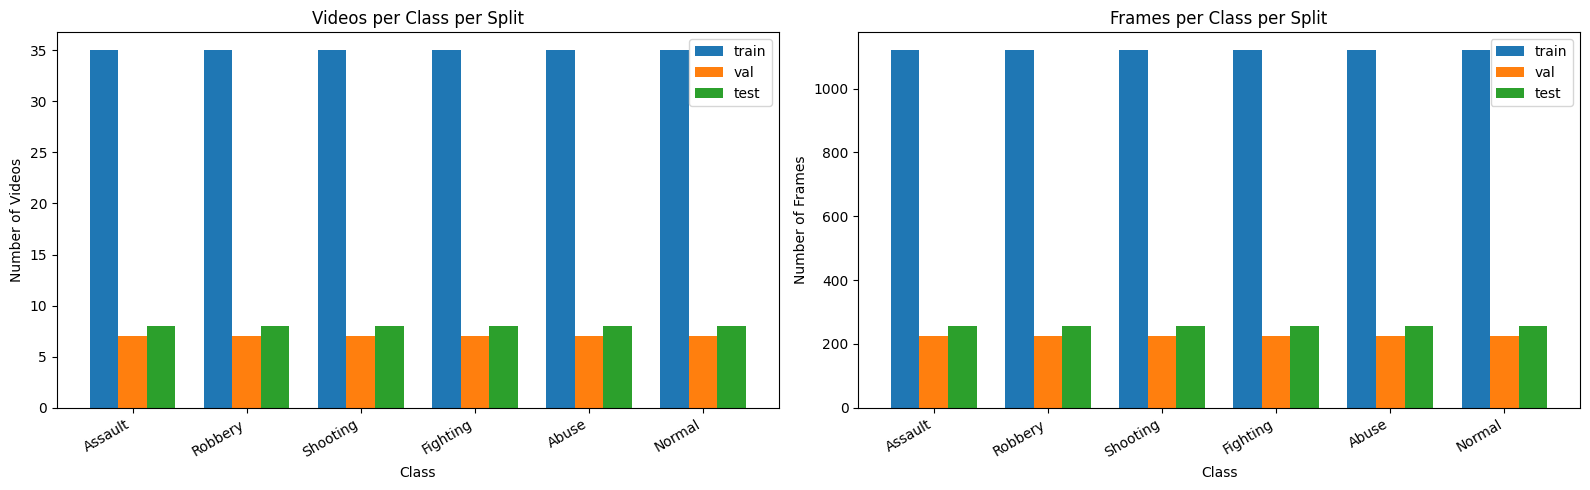

⚠️ LOW Assault: 35 training videos
⚠️ LOW Robbery: 35 training videos
⚠️ LOW Shooting: 35 training videos
⚠️ LOW Fighting: 35 training videos
⚠️ LOW Abuse: 35 training videos
⚠️ LOW Normal: 35 training videos


In [4]:
# ─── Dataset Statistics ────────────────────────────────
classes = list(stats.keys())
splits = ['train', 'val', 'test']
x = np.arange(len(classes))
width = 0.25

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Videos per class
for i, split in enumerate(splits):
    counts = [stats[c].get(split, {}).get('videos', 0) for c in classes]
    ax1.bar(x + i * width, counts, width, label=split)
ax1.set_xlabel('Class')
ax1.set_ylabel('Number of Videos')
ax1.set_title('Videos per Class per Split')
ax1.set_xticks(x + width)
ax1.set_xticklabels(classes, rotation=30, ha='right')
ax1.legend()

# Frames per class
for i, split in enumerate(splits):
    counts = [stats[c].get(split, {}).get('frames', 0) for c in classes]
    ax2.bar(x + i * width, counts, width, label=split)
ax2.set_xlabel('Class')
ax2.set_ylabel('Number of Frames')
ax2.set_title('Frames per Class per Split')
ax2.set_xticks(x + width)
ax2.set_xticklabels(classes, rotation=30, ha='right')
ax2.legend()

plt.tight_layout()
plt.savefig('../outputs/logs/dataset_distribution.png', dpi=150)
plt.show()

# Confirm minimum training data
for c in classes:
    n_train = stats[c].get('train', {}).get('videos', 0)
    status = '✅' if n_train >= 50 else '⚠️ LOW'
    print(f'{status} {c}: {n_train} training videos')